# Setting up colab gpu runtime environment

In [ ]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-fkf7nxhs
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-fkf7nxhs
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# About Dataset

### Dataset

Here the dataset which we are going to use in this guided project is the subset(200 images and its masks) of the original dataset (Massachusetts Roads Dataset) consists of 1171 aerial images of the state of Massachusetts. Each image is 1500×1500 pixels in size, covering an area of 2.25 square kilometers

### Full Dataset

https://www.cs.toronto.edu/~vmnih/data/

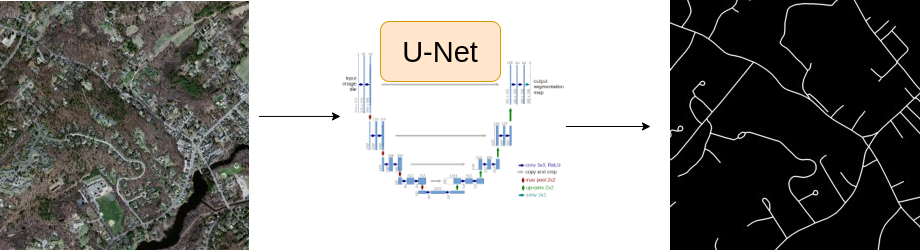

# Download Subset Dataset

In [ ]:
!git clone https://github.com/parth1620/Road_seg_dataset.git

Cloning into 'Road_seg_dataset'...
remote: Enumerating objects: 411, done.
remote: Total 411 (delta 0), reused 0 (delta 0), pack-reused 411 (from 1)
Receiving objects: 100% (411/411), 851.74 MiB | 46.05 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (401/401), done.


# Some Common Imports

In [ ]:
import sys
sys.path.append('/content/Road_seg_dataset')

In [ ]:
import torch
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

# Model Setup Configurations

In [ ]:
CSV_file = '/content/Road_seg_dataset/train.csv'
Data_Path = '/content/Road_seg_dataset/'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHs = 25
LR = 0.003
IMG_SIZE = 512
BATCH_SIZE = 8
ENCODER = 'timm-efficientnet-b0'
WEIGHTS = 'imagenet'

In [ ]:
df = pd.read_csv (CSV_file)
df.head()

,images,masks
0,images/17428750_15.png,masks/17428750_15.png
1,images/23279080_15.png,masks/23279080_15.png
2,images/24179185_15.png,masks/24179185_15.png
3,images/24179035_15.png,masks/24179035_15.png
4,images/11128810_15.png,masks/11128810_15.png


In [ ]:
idx = 15
row = df.iloc[idx]
image_path = Data_Path + row.images
mask_path = Data_Path + row.masks

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) / 255.0

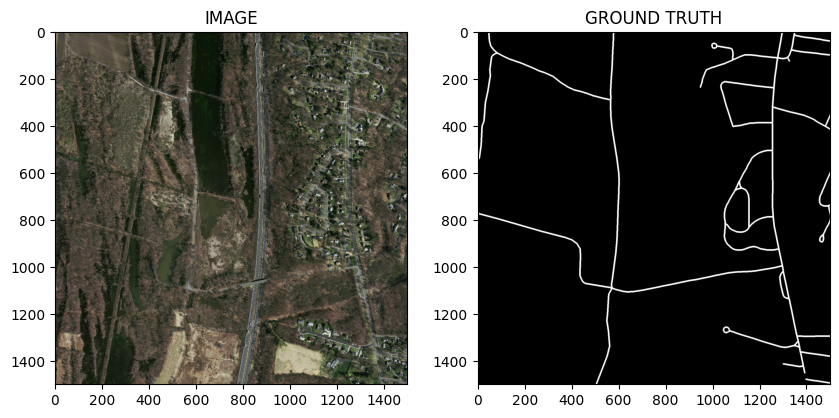

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')

In [ ]:
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)

# Augmentation Functions

albumentation documentation : https://albumentations.ai/docs/

In [ ]:
import albumentations as A

In [ ]:
def get_train_augs():
  return A.Compose([
      A.Resize(IMG_SIZE, IMG_SIZE),
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.5)
  ], is_check_shapes=False)

def get_valid_augs():
  return A.Compose([
      A.Resize(IMG_SIZE, IMG_SIZE)
  ], is_check_shapes=False)

# Create Custom Dataset

In [ ]:
from torch.utils.data import Dataset

In [ ]:
class SegmentationRoadDataset(Dataset):
  def __init__(self, df, augmentations):
    self.df = df
    self.augmentations = augmentations

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]

    # Fix: Prepend Data_Path to the relative image and mask paths
    image_path = Data_Path + row.images
    mask_path = Data_Path + row.masks

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = np.expand_dims(mask, axis = -1)

    if self.augmentations:
      data = self.augmentations(image = image, mask = mask)
      image = data['image']
      mask = data['mask']

    image = np.transpose(image, (2,0,1)).astype(np.float32)
    mask = np.transpose(mask, (2,0,1)).astype(np.float32)

    image = torch.Tensor(image) / 255.0
    mask = torch.round(torch.Tensor(mask) / 255.0)

    return image, mask

In [ ]:
trainset = SegmentationRoadDataset(train_df, get_train_augs())
validset = SegmentationRoadDataset(valid_df, get_valid_augs())

In [ ]:
print(f"Size of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")

Size of Trainset : 159
Size of Validset : 40


In [ ]:
def show_image(image, mask, pred_mask=None):
  f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

  ax1.set_title('IMAGE')
  ax1.imshow(image.cpu().permute(1, 2, 0) if isinstance(image, torch.Tensor) else image)

  ax2.set_title('GROUND TRUTH')
  ax2.imshow(mask.cpu().permute(1, 2, 0) if isinstance(mask, torch.Tensor) else mask, cmap='gray')

  if pred_mask is not None:
    ax3.set_title('PREDICTED MASK')
    ax3.imshow(pred_mask.cpu().permute(1, 2, 0) if isinstance(pred_mask, torch.Tensor) else pred_mask, cmap='gray')

  plt.show()

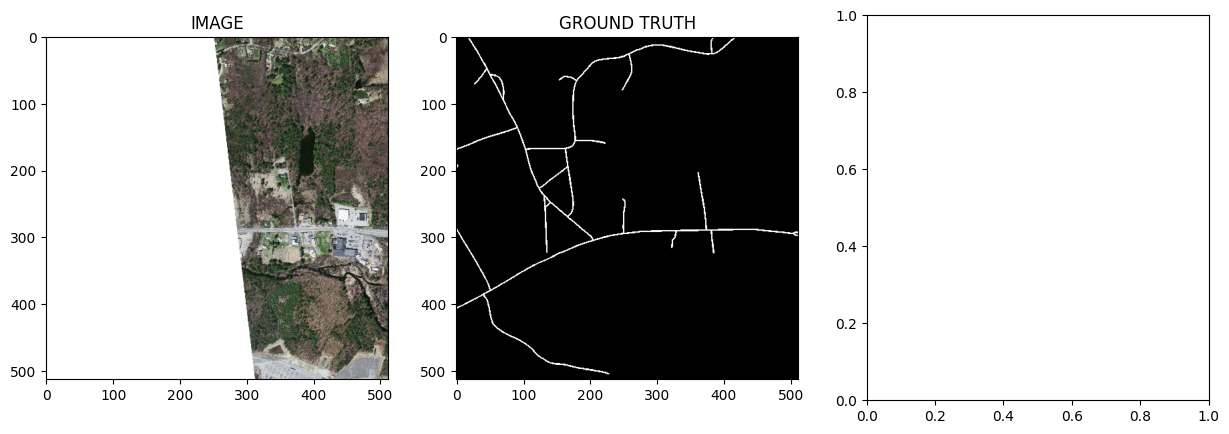

In [ ]:
idx = 45  # Using the same index you had
image, mask = trainset[idx]
show_image(image, mask)

# Load dataset into batches

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE)

In [ ]:
print(f'total number of batches in trainloader : {len(trainloader)}')
print(f'total number of batches in validloader : {len(validloader)}')

total number of batches in trainloader : 20
total number of batches in validloader : 5


In [ ]:
for image, mask in trainloader:
  print(f'image shape : {image.shape}')
  print(f'mask shape : {mask.shape}')
  break # Keeping break for the first batch only

image shape : torch.Size([8, 3, 512, 512])
mask shape : torch.Size([8, 1, 512, 512])


# Create Segmentation Model

segmentation_models_pytorch documentation : https://smp.readthedocs.io/en/latest/

In [ ]:
from torch import nn
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

In [ ]:
class SegmentationModel(nn.Module):
  def __init__(self):
    super(SegmentationModel, self).__init__()

    self.backbone = smp.Unet(
        encoder_name = ENCODER,
        encoder_weights = WEIGHTS,
        in_channels = 3,
        classes =1,
        activation= None
    )
  def forward(self, images, masks = None):
    logits = self.backbone(images)

    if masks is not None:
      loss1 = DiceLoss(mode='binary')(logits, masks)
      loss2 = nn.BCEWithLogitsLoss()(logits, masks)
      return logits, loss1 + loss2
    return logits


In [ ]:
model = SegmentationModel()
model.to(DEVICE);

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

# Create Train and Validation Function

In [ ]:
def train_fn(data_loader,model,optimizer):
  model.train()
  total_loss = 0.0

  for images, masks in tqdm(data_loader):
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()
    logits, loss = model(images, masks)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(data_loader)

In [ ]:
def eval_fn(data_loader,model):
  model.eval()
  total_loss = 0.0

  with torch.no_grad():
    for images, masks in tqdm(data_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits, loss = model(images, masks)
        total_loss += loss.item()

  return total_loss / len(data_loader)

# Train Model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


In [ ]:
best_valid_loss = float('inf')

for i in range(EPOCHs):
  train_loss = train_fn(trainloader, model, optimizer)
  valid_loss = eval_fn(validloader, model)

  if valid_loss < best_valid_loss:
    torch.save(model.state_dict(), 'best_model.pt')
    print('Saved Best Model!')
    best_valid_loss = valid_loss

  print(f'Epoch : {i+1}Train_loss:{train_loss} Valid_loss:{valid_loss}')

100%|██████████| 5/5 [00:03<00:00,  1.35it/s]


Saved Best Model!
Epoch : 1Train_loss:1.3488401412963866 Valid_loss:1.1758027791976928


100%|██████████| 5/5 [00:03<00:00,  1.42it/s]


Saved Best Model!
Epoch : 2Train_loss:0.8699426680803299 Valid_loss:1.1242645025253295


100%|██████████| 5/5 [00:03<00:00,  1.44it/s]


...

Epoch : 23Train_loss:0.5696526393294334 Valid_loss:0.6228253841400146


100%|██████████| 5/5 [00:03<00:00,  1.45it/s]


Epoch : 24Train_loss:0.5715889349579811 Valid_loss:0.6395377397537232


100%|██████████| 5/5 [00:03<00:00,  1.45it/s]

Epoch : 25Train_loss:0.5803465619683266 Valid_loss:0.6483380317687988


# Inference

In [ ]:
idx = 30

model.load_state_dict(torch.load('/content/best_model.pt'))
image, mask = validset[idx]
logits_mask = model(image.to(DEVICE).unsqueeze(0))
logits_mask = logits_mask.cpu().squeeze(0)
pred_mask = torch.sigmoid(logits_mask)
pred_mask = (pred_mask > 0.5)*1.0

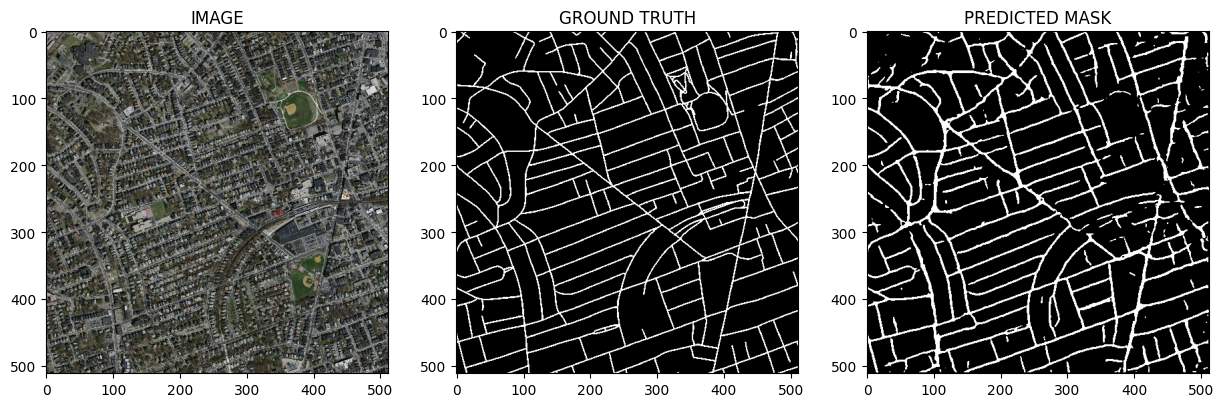

In [ ]:
show_image(image, mask, pred_mask.detach().cpu())